<a href="https://colab.research.google.com/github/Nahi05/Aprendizaje-Automatico-1/blob/main/TP2AA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Trabajo práctico de clustering

*Delgado Nahiara*

## 1. Analiza los datos, inspecciona todas las caracteristicas y el target.

## ¿De qué trata este dataset?

El dataset California Housing Prices contiene información de 20,640 distritos
censales de California del año 1990. Cada fila representa un distrito (block group).

El objetivo original del dataset era predecir el valor mediano de las viviendas
(median_house_value) a partir de características demográficas y geográficas.

Para nuestro trabajo de clustering, vamos a IGNORAR la variable target original
porque queremos encontrar grupos naturales entre los distritos sin usar la
información del precio. Luego podremos analizar si esos grupos tienen sentido
económicamente.

# Analisis exploratorio basico



In [14]:
import kagglehub

path= kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'california-housing-prices' dataset.
Path to dataset files: /kaggle/input/california-housing-prices


In [15]:
! ls /kaggle/input/california-housing-prices/*

/kaggle/input/california-housing-prices/housing.csv


In [16]:
import os
import pandas as pd

files_in_path= os.listdir(path)
print(f"Archivos en el directorio {path}: {files_in_path}")
ruta_al_archivo= path + "/" +files_in_path[0]

print(f"Cargando datos desde: {ruta_al_archivo}")
df= pd.read_csv(ruta_al_archivo)
print("DataFrame 'df' creado. Muestro las primeras 5 filas:")
display(df.head())

Archivos en el directorio /kaggle/input/california-housing-prices: ['housing.csv']
Cargando datos desde: /kaggle/input/california-housing-prices/housing.csv
DataFrame 'df' creado. Muestro las primeras 5 filas:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [17]:
#estructura del dataset

print("informacion general del dataset")

print(f"\n1. dimensiones:")
print(f"filas: {df.shape[0]:,}")
print(f"columnas: {df.shape[1]}")

print(f"\n2. tipos de datos y valores nulos:")
print(df.info())

print(f"\n3. estadisticas descriptivas:")
display(df.describe())

informacion general del dataset

1. dimensiones:
filas: 20,640
columnas: 10

2. tipos de datos y valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

3. estadisticas descriptivas:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [18]:
#analisis de valores nulos

nulos= df.isnull().sum()
porcentaje_nulos= (df.isnull().sum()/len(df)) * 100

tabla_nulos= pd.DataFrame({
    'valores nulos': nulos,
    'porcentaje(%)': porcentaje_nulos
})

display(tabla_nulos[tabla_nulos['valores nulos'] >0])

#cuantas filas tienen al menos un nulo
filas_con_nulos= df.isnull().any(axis=1).sum()
print(f"total de filas con al menos un valor nulo: {filas_con_nulos} de {len(df):,}({filas_con_nulos/len(df)*100:.2f}%)")

,valores nulos,porcentaje(%)
total_bedrooms,207,1.002907


total de filas con al menos un valor nulo: 207 de 20,640(1.00%)


categorias y frecuencias:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64
porcentajes:
ocean_proximity
<1H OCEAN     44.263566
INLAND        31.739341
NEAR OCEAN    12.877907
NEAR BAY      11.094961
ISLAND         0.024225
Name: proportion, dtype: float64


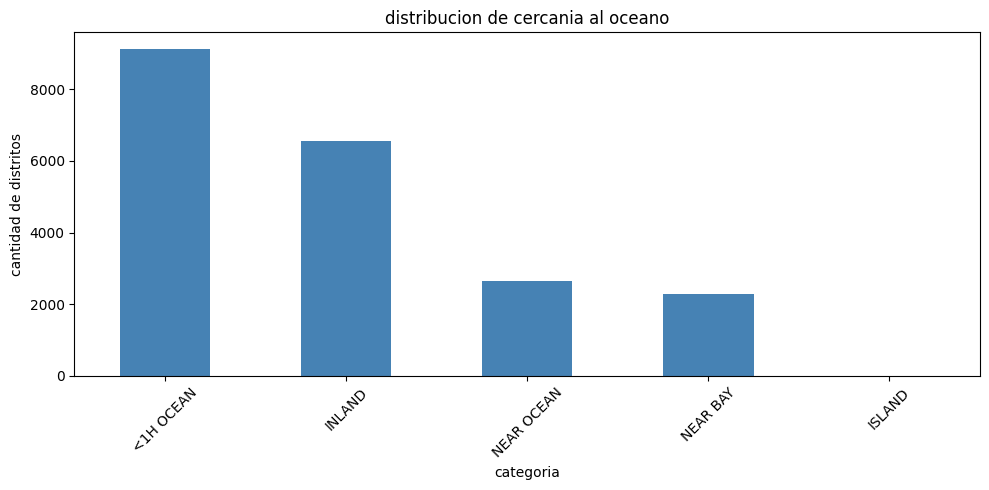

In [19]:
#analisis de variable  categorica ocean_proximity

print("categorias y frecuencias:")
print(df['ocean_proximity'].value_counts())

print("porcentajes:")
print(df['ocean_proximity'].value_counts(normalize=True)*100)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df['ocean_proximity'].value_counts().plot(kind='bar', color='steelblue')
plt.title('distribucion de cercania al oceano')
plt.xlabel('categoria')
plt.ylabel('cantidad de distritos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Preprocesamiento

In [20]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [21]:
#manejo de nulos
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [22]:
#separo numericas y categoricas
numeric_features = ['longitude', 'latitude', 'housing_median_age',
                     'total_rooms', 'total_bedrooms', 'population',
                     'households', 'median_income']

categorical_features = ['ocean_proximity']

In [23]:
#preprocesador
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), numeric_features),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

In [24]:
X_scaled= preprocessor.fit_transform(df)

print(f"Datos listos para clustering: {X_scaled.shape}")

Datos listos para clustering: (20640, 12)


#2. K-means clustering

valor de k

Para determinar el número óptimo de clusters, utilicé dos métricas:

1. **Método del codo (Inercia)**: La inercia disminuye rápidamente hasta k=4,
   y a partir de ahí la reducción es más gradual. Esto indica un "codo" en k=4.

2. **Coeficiente de Silhouette**: El valor más alto se obtuvo en k=2 (0.44),
   pero a partir de k=3 el silhouette disminuye y se estabiliza alrededor de 0.22.

**Decisión:** Considerando el método del codo y que una segmentación con solo
2 clusters sería demasiado general, elegí **k = 4**. Este valor permite una
segmentación más detallada sin perder la calidad de los clusters.

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

k_range= range(2,11)
inertias= []
silhouettes= []
davies_bouldins= []

print("evaluando k desde 2 hasta 10:")

for k in k_range:
  kmeans= KMeans(n_clusters=k, random_state=42, n_init=10)
  labels= kmeans.fit_predict(X_scaled)

  inertias.append(kmeans.inertia_)
  sil= silhouette_score(X_scaled, labels)
  silhouettes.append(sil)
  db= davies_bouldin_score(X_scaled, labels)
  davies_bouldins.append(db)

  print(f"k={k}: Inercia={kmeans.inertia_:.0f}, Silhouette={sil:.3f}, Davies-Bouldin={db:.3f}")

evaluando k desde 2 hasta 10:
k=2: Inercia=130232, Silhouette=0.412, Davies-Bouldin=1.151
k=3: Inercia=97750, Silhouette=0.299, Davies-Bouldin=1.231
k=4: Inercia=84899, Silhouette=0.293, Davies-Bouldin=1.162
k=5: Inercia=77383, Silhouette=0.258, Davies-Bouldin=1.234
k=6: Inercia=70395, Silhouette=0.232, Davies-Bouldin=1.374
k=7: Inercia=64191, Silhouette=0.224, Davies-Bouldin=1.337
k=8: Inercia=59774, Silhouette=0.226, Davies-Bouldin=1.296
k=9: Inercia=56176, Silhouette=0.216, Davies-Bouldin=1.334
k=10: Inercia=53563, Silhouette=0.216, Davies-Bouldin=1.298


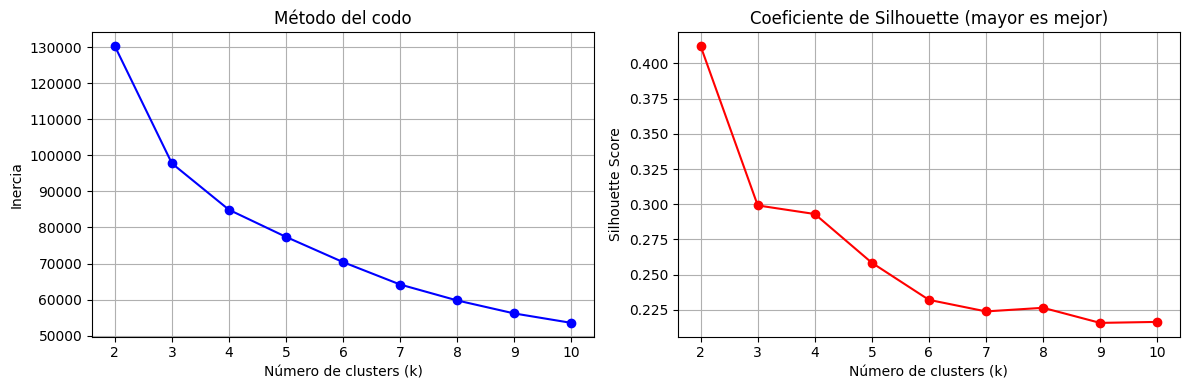

In [26]:
import matplotlib.pyplot as plt

fig, axes= plt.subplots(1,2, figsize=(12,4))

axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo')
axes[0].grid(True)

axes[1].plot(k_range, silhouettes, 'ro-')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Coeficiente de Silhouette (mayor es mejor)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [27]:
k_elegido = 4

kmeans = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nDistribución de clusters:")
print(df['Cluster'].value_counts().sort_index())


Distribución de clusters:
Cluster
0    7710
1    2938
2     312
3    9680
Name: count, dtype: int64


In [32]:
#analisis descriptivo de cada cluster

# Tabla de medias por cluster
cluster_means = df.groupby('Cluster').agg({
    'median_income': 'mean',
    'housing_median_age': 'mean',
    'median_house_value': 'mean',
    'population': 'mean',
    'households': 'mean',
    'latitude': 'mean',
    'longitude': 'mean'
}).round(2)

print(cluster_means)

         median_income  housing_median_age  median_house_value  population  \
Cluster                                                                      
0                 3.74               30.34           193408.64     1034.55   
1                 4.08               18.91           220117.30     2785.24   
2                 4.41               12.17           214673.43     6775.25   
3                 3.90               30.77           213289.33     1151.71   

         households  latitude  longitude  
Cluster                                   
0            377.55     37.98    -121.70  
1           1000.16     35.18    -119.16  
2           2380.90     35.09    -118.88  
3            384.12     33.92    -118.01  


In [33]:
#Distribución de ocean_proximity por cluster
ocean_by_cluster = pd.crosstab(df['Cluster'], df['ocean_proximity'], normalize='index')
print("\nDISTRIBUCIÓN DE OCEAN PROXIMITY POR CLÚSTER (%):")
print(ocean_by_cluster.round(3))


DISTRIBUCIÓN DE OCEAN PROXIMITY POR CLÚSTER (%):
ocean_proximity  <1H OCEAN  INLAND  ISLAND  NEAR BAY  NEAR OCEAN
Cluster                                                         
0                    0.171   0.465   0.000     0.268       0.095
1                    0.495   0.314   0.000     0.069       0.122
2                    0.397   0.455   0.000     0.067       0.080
3                    0.645   0.196   0.001     0.000       0.159


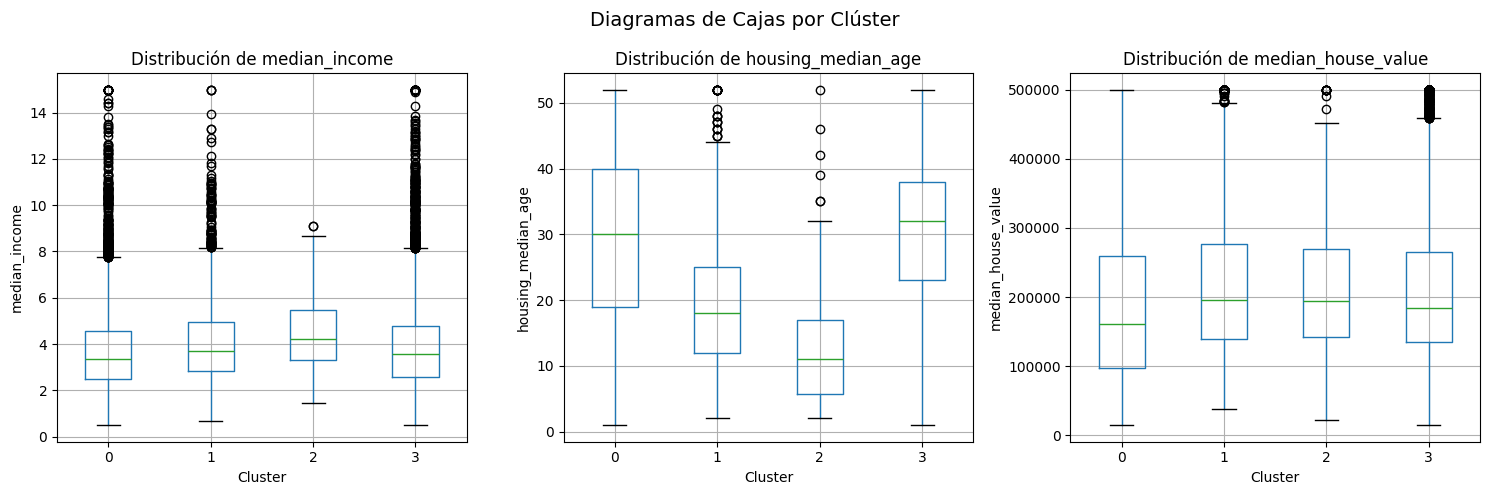

In [34]:
#diagramas de cajas
variables_boxplot = ['median_income', 'housing_median_age', 'median_house_value']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(variables_boxplot):
    df.boxplot(column=var, by='Cluster', ax=axes[i])
    axes[i].set_title(f'Distribución de {var}', fontsize=12)
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(var)

plt.suptitle('Diagramas de Cajas por Clúster', fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
#conteo de puntos por cluster
print("\nDISTRIBUCIÓN DE PUNTOS POR CLÚSTER:")
print(df['Cluster'].value_counts().sort_index())


DISTRIBUCIÓN DE PUNTOS POR CLÚSTER:
Cluster
0    7710
1    2938
2     312
3    9680
Name: count, dtype: int64


#DBSCAN

In [28]:
#busqueda de parametros

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = [0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
min_samples_values = [5, 10, 15, 20]

print("EXPLORACIÓN DE PARÁMETROS DBSCAN")
print(f"{'eps':>6} | {'min_samples':>11} | {'clusters':>8} | {'ruido':>8} | {'% ruido':>8} | {'silhouette':>10}")

for eps in eps_values:
    for min_s in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_s)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        pct_noise = n_noise / len(labels) * 100

        # calcular silhouette solo si hay al menos 2 clusters
        if n_clusters >= 2:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = None

        print(f"{eps:>6} | {min_s:>11} | {n_clusters:>8} | {n_noise:>8} | {pct_noise:>7.1f}% | {str(round(sil,3)) if sil else 'N/A':>10}")

EXPLORACIÓN DE PARÁMETROS DBSCAN
   eps | min_samples | clusters |    ruido |  % ruido | silhouette
   0.3 |           5 |      164 |    14587 |    70.7% |     -0.529
   0.3 |          10 |       27 |    17021 |    82.5% |     -0.469
   0.3 |          15 |        6 |    17968 |    87.1% |     -0.314
   0.3 |          20 |        6 |    18506 |    89.7% |      -0.32
   0.5 |           5 |       96 |     5117 |    24.8% |      -0.39
   0.5 |          10 |       28 |     7706 |    37.3% |     -0.321
   0.5 |          15 |       16 |     9473 |    45.9% |     -0.259
   0.5 |          20 |        9 |    10787 |    52.3% |      -0.16
   0.8 |           5 |       11 |     1248 |     6.0% |       -0.0
   0.8 |          10 |        8 |     1792 |     8.7% |     -0.015
   0.8 |          15 |        8 |     2266 |    11.0% |     -0.031
   0.8 |          20 |        6 |     2774 |    13.4% |     -0.001
   1.0 |           5 |       11 |      662 |     3.2% |     -0.009
   1.0 |          10 |       

In [29]:
#seleccion de parametros
eps_elegido = 1.5
min_samples_elegido = 5

print(f"Parámetros elegidos: eps={eps_elegido}, min_samples={min_samples_elegido}")

Parámetros elegidos: eps=1.5, min_samples=5


In [30]:
#aplico dbscan
dbscan = DBSCAN(eps=eps_elegido, min_samples=min_samples_elegido)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df['Cluster_DBSCAN'])) - (1 if -1 in df['Cluster_DBSCAN'].values else 0)
n_noise = (df['Cluster_DBSCAN'] == -1).sum()
pct_noise = n_noise / len(df) * 100

print(f"Parámetros: eps={eps_elegido}, min_samples={min_samples_elegido}")
print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos considerados ruido: {n_noise} ({pct_noise:.1f}%)")
print(f"Puntos asignados a clusters: {len(df) - n_noise} ({100-pct_noise:.1f}%)")

Parámetros: eps=1.5, min_samples=5
Clusters encontrados: 4
Puntos considerados ruido: 161 (0.8%)
Puntos asignados a clusters: 20479 (99.2%)


In [31]:
#comparacion

print("\nDISTRIBUCIÓN K-MEANS:")
print(df['Cluster'].value_counts().sort_index())

print("\nDISTRIBUCIÓN DBSCAN:")
print(df['Cluster_DBSCAN'].value_counts().sort_index())


DISTRIBUCIÓN K-MEANS:
Cluster
0    7710
1    2938
2     312
3    9680
Name: count, dtype: int64

DISTRIBUCIÓN DBSCAN:
Cluster_DBSCAN
-1      161
 0    20464
 1        5
 2        5
 3        5
Name: count, dtype: int64
